# Iris Recognition - pełny pipeline

In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
from tqdm.auto import tqdm

sys.path.append('..')

from software import (
    load_grayscale_image,
    get_eye_geometry,
    unroll_iris,
    encode_iris,
    compare_iris_codes,
)

from software.visualization import visualize_eye_geometry

## Step 1 - Pojedyczne zdjęcie 

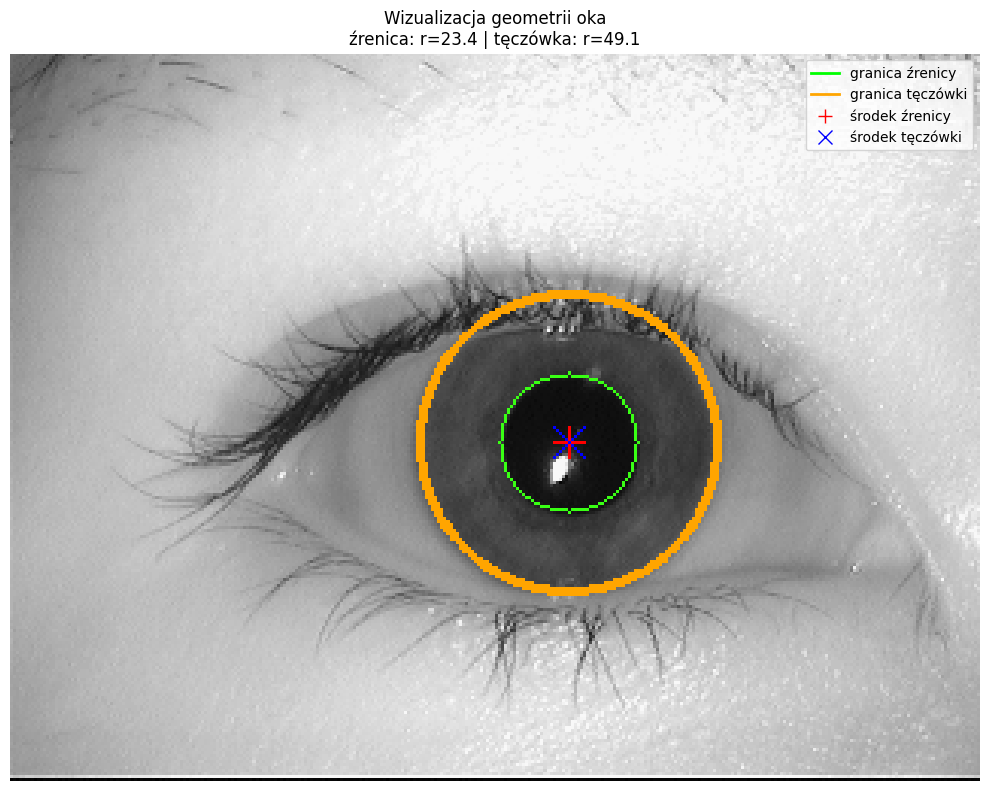

Unrolled iris shape : (60, 360)
Iris code length    : 2048 bits
Bit balance (ones)  : 0.498  (ideal = 0.5)


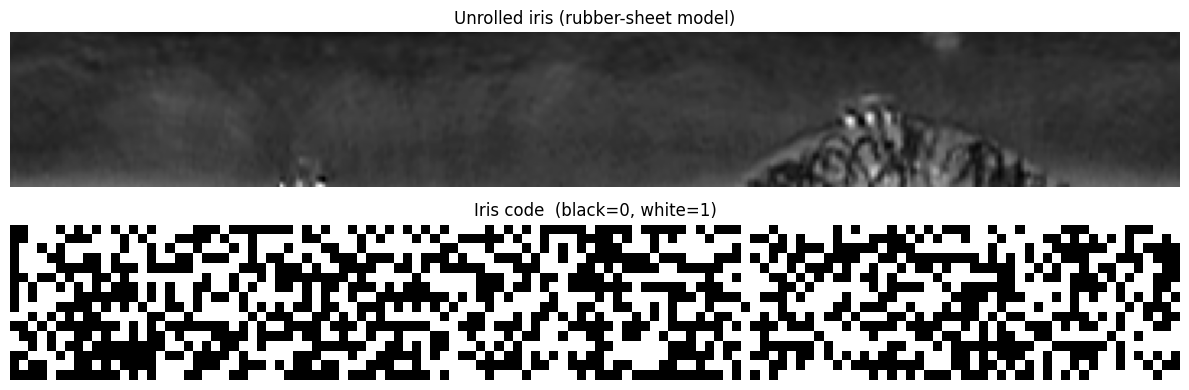

In [4]:
BASE = '../data/MMU-Iris-Database'
demo_path = BASE + '/1/right/aevar1.bmp'

img = load_grayscale_image(demo_path)
pupil, iris = get_eye_geometry(img)
visualize_eye_geometry(img, *pupil, *iris)
iris_rect = unroll_iris(img, pupil, iris)
code = encode_iris(iris_rect)

print('Unrolled iris shape :', iris_rect.shape)
print('Iris code length    :', len(code), 'bits')
print('Bit balance (ones)  : %.3f  (ideal = 0.5)' % code.mean())

fig, axes = plt.subplots(2, 1, figsize=(12, 4))

axes[0].imshow(iris_rect, cmap='gray', aspect='auto')
axes[0].set_title('Unrolled iris (rubber-sheet model)')
axes[0].axis('off')

axes[1].imshow(code.reshape(16, -1), cmap='binary', aspect='auto', interpolation='nearest')
axes[1].set_title('Iris code  (black=0, white=1)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 2 - Zakodowanie wszystkich dostępnych zdjęć

In [5]:
def _valid_geometry(pupil, iris, img_h=240, img_w=320):
    """Rejects clearly wrong detections (e.g. failed iterations returning zeros)."""
    rp, ri = pupil[2], iris[2]
    return (
        8 < rp < 60
        and ri > rp * 1.3
        and ri < min(img_h, img_w) * 0.60
    )


records = []   # {subject, eye, name, code}
failures = []

for subj in tqdm(sorted([f for f in os.listdir(BASE) if os.path.isdir(os.path.join(BASE, f))], key=int), desc='Subjects'):
    subj_dir = os.path.join(BASE, subj)

    for eye in ('left', 'right'):
        eye_dir = os.path.join(subj_dir, eye)
        if not os.path.isdir(eye_dir):
            continue

        for fname in sorted(os.listdir(eye_dir)):
            if not fname.endswith('.bmp'):
                continue

            path = os.path.join(eye_dir, fname)
            img = load_grayscale_image(path)
            if img is None:
                failures.append(path)
                continue

            try:
                pupil, iris = get_eye_geometry(img)
                if not _valid_geometry(pupil, iris):
                    failures.append(path)
                    continue

                iris_rect = unroll_iris(img, pupil, iris)
                code = encode_iris(iris_rect)

                records.append({
                    'subject': int(subj),
                    'eye':     eye,
                    'name':    fname,
                    'code':    code,
                })
            except Exception:
                failures.append(path)

print('Encoded :', len(records), 'images')
print('Failed  :', len(failures), 'images  (bad geometry or load error)')

Subjects:   0%|          | 0/45 [00:00<?, ?it/s]

Encoded : 437 images
Failed  : 13 images  (bad geometry or load error)


## Step 3 - Generacja par tych samych oczu oraz różnych

In [6]:
# group by (subject, eye)
groups = defaultdict(list)
for r in records:
    groups[(r['subject'], r['eye'])].append(r['code'])

genuine_hd  = []
impostor_hd = []

# genuine: same subject, same eye, different capture
for codes in groups.values():
    for c1, c2 in combinations(codes, 2):
        genuine_hd.append(compare_iris_codes(c1, c2, n_shifts=15))

# impostor: different subjects (one pair per group combination, then subsample)
rng = np.random.default_rng(42)
group_keys = list(groups.keys())

impostor_pairs = [
    (groups[ka][0], groups[kb][0])
    for i, ka in enumerate(group_keys)
    for kb in group_keys[i + 1:]
    if ka[0] != kb[0]
]

if len(impostor_pairs) > 4000:
    idx = rng.choice(len(impostor_pairs), 4000, replace=False)
    impostor_pairs = [impostor_pairs[i] for i in idx]

for c1, c2 in tqdm(impostor_pairs, desc='Impostor pairs'):
    impostor_hd.append(compare_iris_codes(c1, c2, n_shifts=3))

genuine_hd  = np.array(genuine_hd)
impostor_hd = np.array(impostor_hd)

print('Genuine  pairs: %d   mean HD: %.4f   std: %.4f' % (len(genuine_hd),  genuine_hd.mean(),  genuine_hd.std()))
print('Impostor pairs: %d   mean HD: %.4f   std: %.4f' % (len(impostor_hd), impostor_hd.mean(), impostor_hd.std()))

Impostor pairs:   0%|          | 0/3872 [00:00<?, ?it/s]

Genuine  pairs: 864   mean HD: 0.4226   std: 0.0317
Impostor pairs: 3872   mean HD: 0.4658   std: 0.0168


## Step 4 - Rozkład dystansu Hamminga

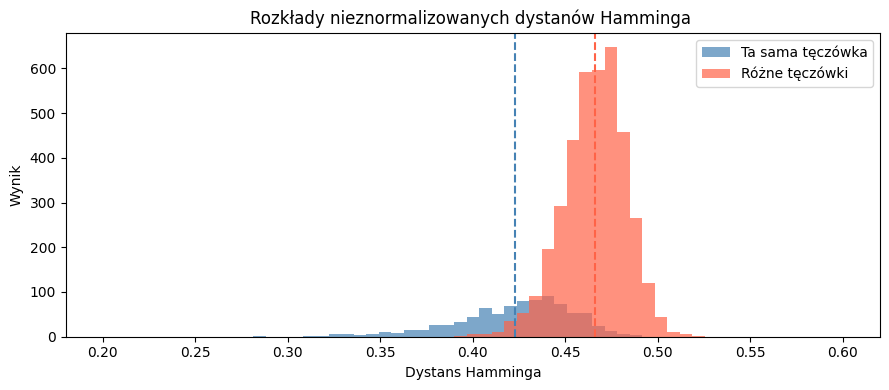

In [18]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0.2, 0.6, 60)

ax.hist(genuine_hd,  bins=bins, alpha=0.7, color='steelblue', label='Ta sama tęczówka')
ax.hist(impostor_hd, bins=bins, alpha=0.7, color='tomato',    label='Różne tęczówki')

ax.axvline(genuine_hd.mean(),  color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(impostor_hd.mean(), color='tomato',    linestyle='--', linewidth=1.5)

ax.set_xlabel('Dystans Hamminga')
ax.set_ylabel('Wynik')
ax.set_title('Rozkłady nieznormalizowanych dystanów Hamminga ')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 - krzywe EER i ROC

In [15]:
thresholds = np.linspace(0, 1, 500)
far = np.array([np.mean(impostor_hd <= t) for t in thresholds])  # impostors accepted
frr = np.array([np.mean(genuine_hd  >  t) for t in thresholds])  # genuines rejected

eer_idx       = np.argmin(np.abs(far - frr))
eer           = (far[eer_idx] + frr[eer_idx]) / 2.0
eer_threshold = thresholds[eer_idx]

print('EER          : %.2f%%' % (eer * 100))
print('At threshold : %.4f'   % eer_threshold)
print('FAR @ EER    : %.2f%%' % (far[eer_idx] * 100))
print('FRR @ EER    : %.2f%%' % (frr[eer_idx] * 100))

EER          : 17.69%
At threshold : 0.4509
FAR @ EER    : 17.79%
FRR @ EER    : 17.59%


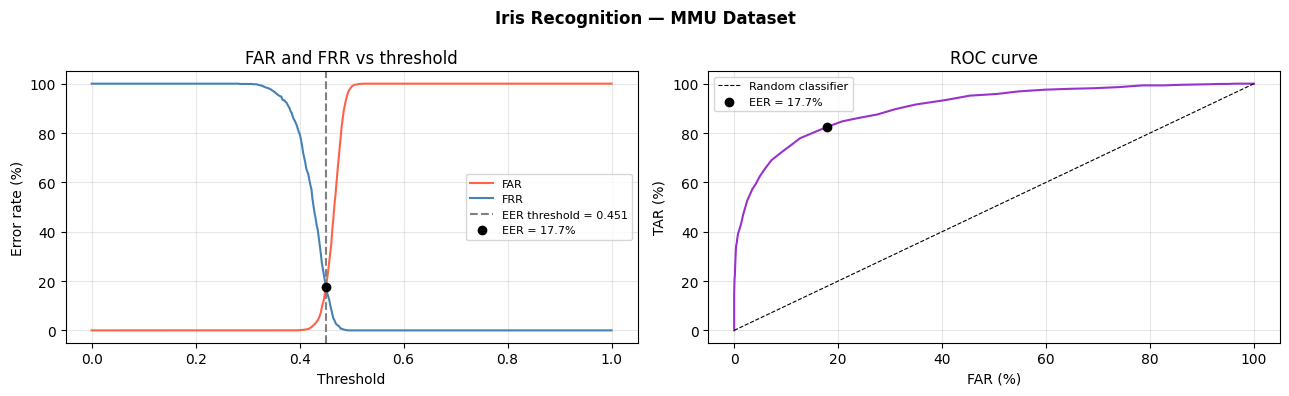

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, far * 100, color='tomato',    label='FAR')
axes[0].plot(thresholds, frr * 100, color='steelblue', label='FRR')
axes[0].axvline(eer_threshold, color='gray', linestyle='--',
                label='EER threshold = %.3f' % eer_threshold)
axes[0].scatter([eer_threshold], [eer * 100], color='black', zorder=5,
                label='EER = %.1f%%' % (eer * 100))
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Error rate (%)')
axes[0].set_title('FAR and FRR vs threshold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

tar = 1.0 - frr
axes[1].plot(far * 100, tar * 100, color='darkorchid')
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=0.8, label='Random classifier')
axes[1].scatter([far[eer_idx] * 100], [tar[eer_idx] * 100], color='black',
                zorder=5, label='EER = %.1f%%' % (eer * 100))
axes[1].set_xlabel('FAR (%)')
axes[1].set_ylabel('TAR (%)')
axes[1].set_title('ROC curve')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Iris Recognition — MMU Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 - Przykładowe porównanie

In [17]:
example_group = next(v for v in groups.values() if len(v) >= 2)
c_same_1, c_same_2 = example_group[0], example_group[1]

group_values = list(groups.values())
c_diff_1, c_diff_2 = group_values[0][0], group_values[-1][0]

hd_same = compare_iris_codes(c_same_1, c_same_2, n_shifts=15)
hd_diff = compare_iris_codes(c_diff_1, c_diff_2, n_shifts=3)

print('Same person  — HD = %.4f  → %s' % (hd_same, 'MATCH' if hd_same <= eer_threshold else 'NO MATCH'))
print('Diff persons — HD = %.4f  → %s' % (hd_diff, 'MATCH' if hd_diff <= eer_threshold else 'NO MATCH'))

Same person  — HD = 0.3530  → MATCH
Diff persons — HD = 0.4761  → NO MATCH
